In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [3]:
# Load Dataset
data = pd.read_csv('dirty_cafe_sales.csv') # load the data with pandas
cafe_data = data.copy() # copy the data

In [4]:
# Inspect Dataset
cafe_data.info() # data information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [5]:
cafe_data.describe() # data statistical information

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [6]:
cafe_data.duplicated().sum() # checking for duplicates in data

np.int64(0)

In [7]:
cafe_data.isnull().sum() # checking for nulls in data

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [8]:
# Drop rows where a single column is null
cafe_data = cafe_data.dropna(subset=['Transaction ID']) # Drop rows where Transaction ID is null

In [9]:
# If you only want the non-null values of that column (as a Series)
# non_null_quantity = cafe_data['Transaction ID'].dropna()

In [10]:
# Cleaning Duplicates in dataset
cafe_data.drop_duplicates(inplace = True)

In [11]:
# printing the all columns
cafe_data.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [12]:
# conveting the data form object type to numeric type
numeric_col = ['Quantity', 'Price Per Unit', 'Total Spent']
for col in numeric_col:
    cafe_data[col] = pd.to_numeric(cafe_data[col].astype(str).
        str.replace(',', '').str.strip(), errors = 'coerce')

In [13]:
# conveting the date data form object type to datetime type
cafe_data['Transaction Date'] = pd.to_datetime(cafe_data['Transaction Date'],errors='coerce',
                                               infer_datetime_format= True)

C:\Users\hp\AppData\Local\Temp\ipykernel_3212\4140010534.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  cafe_data['Transaction Date'] = pd.to_datetime(cafe_data['Transaction Date'],errors='coerce',


In [14]:
# # convert numeric columns to object (string) columns in pandas, you cast them with .astype(str).
# cols_to_object = ['Quantity', 'Price Per Unit', 'Total Spent']
# for col in cols_to_object:
#     cafe_data[col] = cafe_data[col].astype(str)
# #You can also control how numbers look when converting
# cafe_data['Price Per Unit'] = cafe_data['Price Per Unit'].map(lambda x: f"{x:.2f}")

In [15]:
# # Convert datetime to numeric/integer (nanoseconds since epoch)
# cafe_data['_Transaction_int'] = cafe_data['Transaction Date'].view('int64')
# # Convert datetime to string temporarily
# date_time_cols = ['Transaction Date']
# cafe_data[date_time_cols] = cafe_data[date_time_cols].astype('object')

In [16]:
# sperate the numeric columns and categorical columns
numeric_cols = cafe_data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = cafe_data.select_dtypes(include=['object']).columns.tolist()
date_time_cols = cafe_data.select_dtypes(include=['datetime64[ns, UTC]', 'datetime64[ns]']).columns.tolist()

In [17]:
categorical_cols

['Transaction ID', 'Item', 'Payment Method', 'Location']

In [18]:
numeric_cols

['Quantity', 'Price Per Unit', 'Total Spent']

In [19]:
date_time_cols

['Transaction Date']

In [20]:
from sklearn.impute import SimpleImputer

# handle missing values for numeric columns using mean strategy
num_imputer = SimpleImputer(strategy='mean')
cafe_data[numeric_cols] = num_imputer.fit_transform(cafe_data[numeric_cols])

# handle missing values for categorical columns using most frequent strategy
cat_imputer = SimpleImputer(strategy='most_frequent')
cafe_data[categorical_cols] = cat_imputer.fit_transform(cafe_data[categorical_cols])

# handle missing values for categorical columns using most frequent strategy
cafe_data[date_time_cols] = cafe_data[date_time_cols].astype('object') # Convert datetime to string temporarily
date_time_imputer = SimpleImputer(strategy='most_frequent')
cafe_data[date_time_cols] = date_time_imputer.fit_transform(cafe_data[date_time_cols])
# Convert back to datetime
for col in date_time_cols:
    cafe_data[col] = pd.to_datetime(cafe_data[col])

In [21]:
# # Numeric way: convert dates to integers
# # 1) Convert datetime to integer (nanoseconds since epoch)
# cafe_data['_Transaction_int'] = cafe_data['Transaction Date'].view('int64')

# # 2) Impute using mean
# date_num_imputer = SimpleImputer(strategy='mean')
# cafe_data['_Transaction_int'] = date_num_imputer.fit_transform(
#     cafe_data[['_Transaction_int']])

# # 3) Convert back to datetime
# cafe_data['Transaction Date'] = pd.to_datetime(
#     cafe_data['_Transaction_int'])

# # 4) Optionally drop helper column
# cafe_data.drop(columns=['_Transaction_int'], inplace=True)

In [22]:
# Outliers
# Cap outliers in Total Spent using IQR (1.5 rule, then 99th percentile winsorize if needed)
Q1 = cafe_data['Total Spent'].quantile(0.25)
Q3 = cafe_data['Total Spent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_before = ((cafe_data['Total Spent'] < lower_bound) | (cafe_data['Total Spent'] > upper_bound)).sum()
cafe_data['Total Spent'] = np.clip(cafe_data['Total Spent'], lower_bound, upper_bound)

print(f"Outliers capped: {outliers_before} (bounds: {lower_bound:.2f} - {upper_bound:.2f})")

# Optional: Further cap at 99th percentile for extreme sanity
p99 = cafe_data['Total Spent'].quantile(0.99)
cafe_data['Total Spent'] = cafe_data['Total Spent'].clip(upper=p99)
print(f"99th percentile cap: {p99:.2f}")

Outliers capped: 259 (bounds: -8.00 - 24.00)
99th percentile cap: 24.00


In [23]:
# Verify dtypes
print("\nDtypes:\n", cafe_data.dtypes)
print(f"Final shape: {cafe_data.shape}")


Dtypes:
 Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object
Final shape: (10000, 8)


In [24]:
cafe_data.to_csv('cafe_data_cleaned.csv', index=False)
print("Saved 'cafe_data_cleaned.csv'")

Saved 'cafe_data_cleaned.csv'


In [25]:
import pandas as pd

# Load the cleaned CSV
df_clean = pd.read_csv('cafe_data_cleaned.csv')

# Quick checks
print(df_clean.shape)        # rows, columns
print(df_clean.dtypes)       # data types
print(df_clean.head())             # first 5 rows
df_clean.isnull().sum()      # remaining missing values

(10000, 8)
Transaction ID       object
Item                 object
Quantity            float64
Price Per Unit      float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
dtype: object
  Transaction ID    Item  Quantity  Price Per Unit  Total Spent  \
0    TXN_1961373  Coffee       2.0             2.0     4.000000   
1    TXN_4977031    Cake       4.0             3.0    12.000000   
2    TXN_4271903  Cookie       4.0             1.0     8.924352   
3    TXN_7034554   Salad       2.0             5.0    10.000000   
4    TXN_3160411  Coffee       2.0             2.0     4.000000   

   Payment Method  Location Transaction Date  
0     Credit Card  Takeaway       2023-09-08  
1            Cash  In-store       2023-05-16  
2     Credit Card  In-store       2023-07-19  
3         UNKNOWN   UNKNOWN       2023-04-27  
4  Digital Wallet  In-store       2023-06-11  


Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [26]:
# Feature Engineering
 
df_clean['Transaction Date'] = pd.to_datetime(df_clean['Transaction Date'], errors='coerce')# Ensure datetime
df_clean = df_clean.dropna(subset=['Transaction Date'])  # Drop invalids

# 1. Add day_of_week and month
df_clean['day_of_week'] = df_clean['Transaction Date'].dt.day_name()
df_clean['month'] = df_clean['Transaction Date'].dt.month_name()

print("New date feats sample:\n", df_clean[['Transaction Date', 'day_of_week', 'month']].head())

# 2. total_by_customer: Group by Transaction ID (proxy customer), sum Total Spent
customer_totals = df_clean.groupby('Transaction ID')['Total Spent'].sum().reset_index()
customer_totals.columns = ['Transaction ID', 'total_by_customer']
df_clean = df_clean.merge(customer_totals, on='Transaction ID', how='left')

# Verify
print("\ndf dtypes new:\n", df_clean[['day_of_week', 'month', 'total_by_customer']].dtypes)
print("\nCustomer totals stats:\n", df_clean['total_by_customer'].describe())
print("Feat matrix shape: ", df_clean.shape)

New date feats sample:
   Transaction Date day_of_week      month
0       2023-09-08      Friday  September
1       2023-05-16     Tuesday        May
2       2023-07-19   Wednesday       July
3       2023-04-27    Thursday      April
4       2023-06-11      Sunday       June

df dtypes new:
 day_of_week           object
month                 object
total_by_customer    float64
dtype: object

Customer totals stats:
 count    10000.000000
mean         8.898452
std          5.787763
min          1.000000
25%          4.000000
50%          8.000000
75%         12.000000
max         24.000000
Name: total_by_customer, dtype: float64
Feat matrix shape:  (10000, 11)


In [27]:
df_clean.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date', 'day_of_week',
       'month', 'total_by_customer'],
      dtype='object')

Text(0.5, 1.0, 'Total Spent Distribution Post-Cleaning')

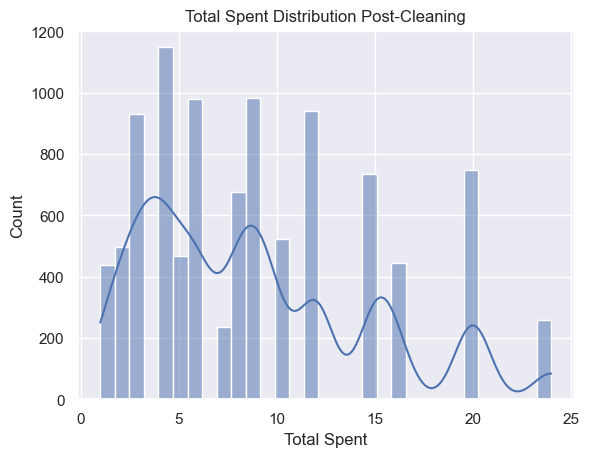

In [28]:
# Total Spent Distribution
sns.histplot(df_clean['Total Spent'], kde=True) # Spot normality after outlier removal 
plt.title('Total Spent Distribution Post-Cleaning')

<Axes: >

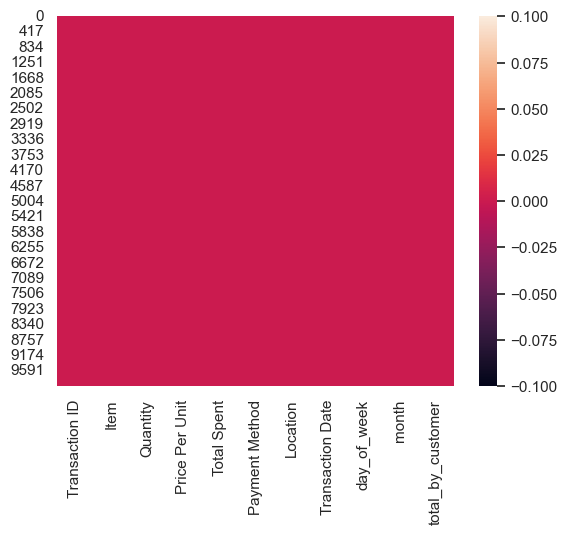

In [29]:
# Missing Values Heatmap and Pre-clean audit
sns.heatmap(df_clean.isnull(), cbar=True)

Text(0.5, 1.0, 'Sales by Weekday')

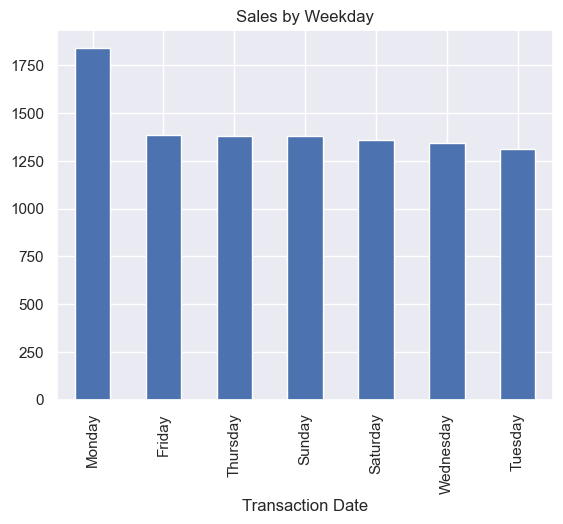

In [30]:
#Sales by Day and Trend storytelling
df_clean['Transaction Date'].dt.day_name().value_counts().plot(kind='bar'); plt.title('Sales by Weekday')

<Axes: ylabel='count'>

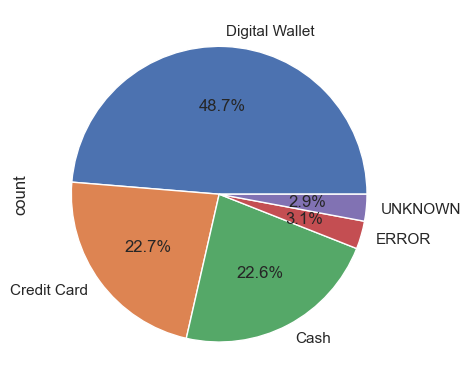

In [31]:
# Payment Methods Pie and Categorical insights.
df_clean['Payment Method'].value_counts().plot(kind='pie', autopct='%1.1f%%')

<Axes: xlabel='Transaction ID', ylabel='Total Spent'>

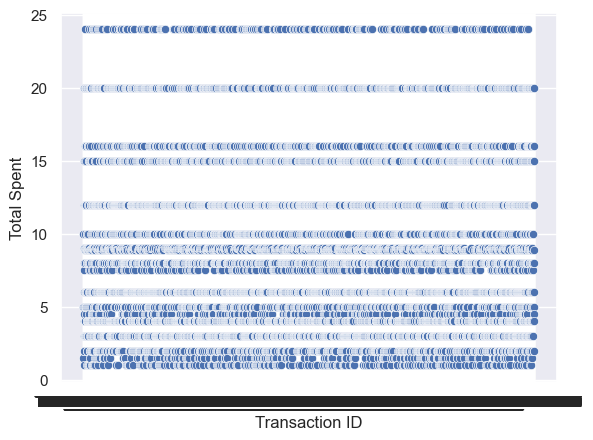

In [32]:
# Top Customers Scatter and High-value outliers
sns.scatterplot(data=df_clean.groupby('Transaction ID')['Total Spent'].sum().reset_index(), x='Transaction ID', y='Total Spent')